ppg_dalia

In [ ]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import pickle

# Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Paths
base_path = '/content/drive/MyDrive/PulseWatch-AI'
ppg_dalia_dataset = os.path.join(base_path, 'datasets/raw/ppg_dalia')
ppg_study_folder = os.path.join(ppg_dalia_dataset, 'PPG_FieldStudy')

# Find all subjects
subject_folders = sorted([f for f in os.listdir(ppg_study_folder)
                         if os.path.isdir(os.path.join(ppg_study_folder, f))
                         and f.startswith('S')])

# Find all .pkl files
all_pkl_files = []
for subject_folder in subject_folders:
    pkl_file = os.path.join(ppg_study_folder, subject_folder, f"{subject_folder}.pkl")
    if os.path.exists(pkl_file):
        all_pkl_files.append(pkl_file)

print("=" * 50)
print("✅ PULSEWATCH AI - DATASET READY")
print("=" * 50)
print(f"📁 Dataset: {ppg_study_folder}")
print(f"📊 Subjects: {len(all_pkl_files)}/15")
print(f"🎯 Ready for Module 2: Data Loading")
print("=" * 50)

✅ PULSEWATCH AI - DATASET READY
📁 Dataset: /content/drive/MyDrive/PulseWatch-AI/datasets/raw/ppg_dalia/PPG_FieldStudy
📊 Subjects: 15/15
🎯 Ready for Module 2: Data Loading


pulsedb

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import h5py

# --- Mount Drive ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- Paths ---
base_path = '/content/drive/MyDrive/PulseWatch-AI'
pulsedb_folder = os.path.join(base_path, 'datasets/raw/pulsedb')
segment_folder = os.path.join(pulsedb_folder, 'Segment_Files')

# Define the two subfolders to search
pulsedb_segment_MIMIC = os.path.join(segment_folder, 'PulseDB_MIMIC')
pulsedb_segment_VitalDB = os.path.join(segment_folder, 'PulseDB_Vital')

# --- Find all .mat files ---
all_mat_files = []

# Find all files in the MIMIC folder
mimic_files = glob.glob(os.path.join(pulsedb_segment_MIMIC, '*.mat'))
all_mat_files.extend(mimic_files)

# Find all files in the VitalDB folder
vitaldb_files = glob.glob(os.path.join(pulsedb_segment_VitalDB, '*.mat'))
all_mat_files.extend(vitaldb_files)

# --- Summary Printout ---
print("=" * 50)
print("✅ PULSEWATCH AI - PHASE 1 DATASET READY")
print("=" * 50)
print(f"📁 Searched Paths:")
print(f"   - {pulsedb_segment_MIMIC}")
print(f"   - {pulsedb_segment_VitalDB}")
print(f"📊 Total Segments Found: {len(all_mat_files)}")
print(f"   - (MIMIC: {len(mimic_files)}, VitalDB: {len(vitaldb_files)})")
print(f"🎯 Ready for Module 2: Data Loading")
print("=" * 50)

Mounted at /content/drive
✅ PULSEWATCH AI - PHASE 1 DATASET READY
📁 Searched Paths:
   - /content/drive/MyDrive/PulseWatch-AI/datasets/raw/pulsedb/Segment_Files/PulseDB_MIMIC
   - /content/drive/MyDrive/PulseWatch-AI/datasets/raw/pulsedb/Segment_Files/PulseDB_Vital
📊 Total Segments Found: 5361
   - (MIMIC: 2423, VitalDB: 2938)
🎯 Ready for Module 2: Data Loading


load and inspect one .mat file from pulsdb

✅ PULSEWATCH AI - MODULE 2: DATA LOADING (v4)
Loading: p080737.mat from MIMIC folder...
✅ File loaded successfully!

Available signals inside 'Subj_Wins': ['ABP_F', 'ABP_Lag', 'ABP_Raw', 'ABP_SPeaks', 'ABP_Turns', 'Age', 'CaseID', 'ECG_F', 'ECG_RPeaks', 'ECG_Raw', 'ECG_Record', 'ECG_Record_F', 'Gender', 'IncludeFlag', 'PPG_ABP_Corr', 'PPG_F', 'PPG_Raw', 'PPG_Record', 'PPG_Record_F', 'PPG_SPeaks', 'PPG_Turns', 'SegDBP', 'SegSBP', 'SegmentID', 'SubjectID', 'T', 'WinID', 'WinSeqID']

Found 'PPG_Record_F'. Contains 1 segments.
Loaded Segment 0 'PPG_Record_F'. Shape: (1250,)
Found 'ECG_Record_F'. Contains 1 segments.
Loaded Segment 0 'ECG_Record_F'. Shape: (1250,)

Visualizing Segment 0 signals...


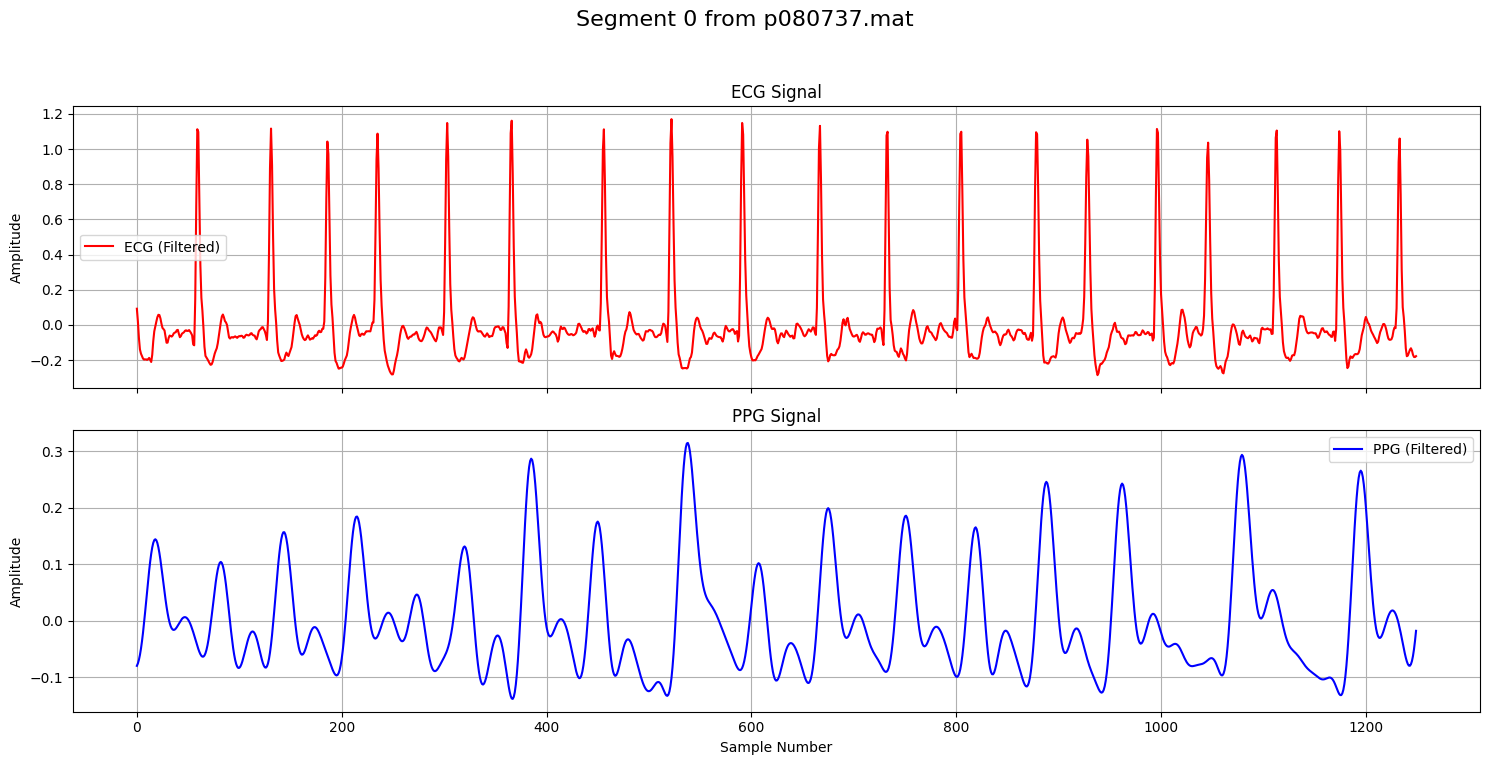

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import h5py

# --- Mount Drive (if not already mounted) ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- Paths (same as before) ---
base_path = '/content/drive/MyDrive/PulseWatch-AI'
pulsedb_folder = os.path.join(base_path, 'datasets/raw/pulsedb')
segment_folder = os.path.join(pulsedb_folder, 'Segment_Files')
pulsedb_segment_MIMIC = os.path.join(segment_folder, 'PulseDB_MIMIC')

print("=" * 50)
print("✅ PULSEWATCH AI - MODULE 2: DATA LOADING (v4)")
print("=" * 50)

# --- Load an Example File ---
example_file_name = 'p080737.mat'
example_file_path = os.path.join(pulsedb_segment_MIMIC, example_file_name)

# Initialize signal variables
ppg_signal = None
ecg_signal = None

try:
    print(f"Loading: {example_file_name} from MIMIC folder...")

    with h5py.File(example_file_path, 'r') as mat_data:
        print("✅ File loaded successfully!")

        if 'Subj_Wins' in mat_data:
            data_group = mat_data['Subj_Wins']
            print(f"\nAvailable signals inside 'Subj_Wins': {list(data_group.keys())}")

            # --- CORRECTED: Load PPG Signal ---
            if 'PPG_Record_F' in data_group:
                # 1. Load the array of *references*
                ppg_ref_array = data_group['PPG_Record_F']
                print(f"\nFound 'PPG_Record_F'. Contains {len(ppg_ref_array)} segments.")

                # 2. Get the reference for the *first* segment (index 0)
                # Extract the scalar value from the array
                first_ppg_ref = ppg_ref_array[0, 0]  # Get scalar reference

                # 3. Dereference it to get the actual HDF5 data object
                ppg_signal_data = mat_data[first_ppg_ref]

                # 4. Read the data into a numpy array
                ppg_signal = np.squeeze(ppg_signal_data[:])
                print(f"Loaded Segment 0 'PPG_Record_F'. Shape: {ppg_signal.shape}")
            else:
                print("❌ 'PPG_Record_F' not found inside 'Subj_Wins'.")

            # --- CORRECTED: Load ECG Signal ---
            if 'ECG_Record_F' in data_group:
                # 1. Load the array of *references*
                ecg_ref_array = data_group['ECG_Record_F']
                print(f"Found 'ECG_Record_F'. Contains {len(ecg_ref_array)} segments.")

                # 2. Get the reference for the *first* segment
                # Extract the scalar value from the array
                first_ecg_ref = ecg_ref_array[0, 0]  # Get scalar reference

                # 3. Dereference it
                ecg_signal_data = mat_data[first_ecg_ref]

                # 4. Read into numpy
                ecg_signal = np.squeeze(ecg_signal_data[:])
                print(f"Loaded Segment 0 'ECG_Record_F'. Shape: {ecg_signal.shape}")
            else:
                print("❌ 'ECG_Record_F' not found inside 'Subj_Wins'.")
        else:
            print("❌ ERROR: Cannot find the main 'Subj_Wins' data group in the file.")

    # --- Plot the signals (if they were loaded) ---
    if ppg_signal is not None or ecg_signal is not None:
        print("\nVisualizing Segment 0 signals...")
        fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
        fig.suptitle(f"Segment 0 from {example_file_name}", fontsize=16)

        # Plot ECG
        if ecg_signal is not None:
            axes[0].plot(ecg_signal, label='ECG (Filtered)', color='red')
            axes[0].set_title("ECG Signal")
            axes[0].set_ylabel("Amplitude")
            axes[0].grid(True)
            axes[0].legend()
        else:
            axes[0].set_title("ECG Signal (Not Found)")

        # Plot PPG
        if ppg_signal is not None:
            axes[1].plot(ppg_signal, label='PPG (Filtered)', color='blue')
            axes[1].set_title("PPG Signal")
            axes[1].set_xlabel("Sample Number")
            axes[1].set_ylabel("Amplitude")
            axes[1].grid(True)
            axes[1].legend()
        else:
            axes[1].set_title("PPG Signal (Not Found)")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
        print("\nNo signals were loaded, skipping plot.")

except FileNotFoundError:
    print(f"\n❌ ERROR: File not found at path: {example_file_path}")
except Exception as e:
    print(f"\n❌ An error occurred: {e}")
    import traceback
    traceback.print_exc()